In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# =========================================================
# =========================================================
# ✱ 1. EDA – RECEITAS (JSON)
# =========================================================
# =========================================================

# Carregar JSON corretamente
with open("receitas.json") as f:
    data = json.load(f)

df_eda = pd.json_normalize(data)

print("\nℹ️ Estrutura do dataset:")
print(df_eda.info())


ℹ️ Estrutura do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20130 entries, 0 to 20129
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   directions   20111 non-null  object 
 1   fat          15908 non-null  float64
 2   date         20111 non-null  object 
 3   categories   20111 non-null  object 
 4   calories     15976 non-null  float64
 5   desc         13495 non-null  object 
 6   protein      15929 non-null  float64
 7   rating       20100 non-null  float64
 8   title        20111 non-null  object 
 9   ingredients  20111 non-null  object 
 10  sodium       15974 non-null  float64
dtypes: float64(5), object(6)
memory usage: 1.7+ MB
None


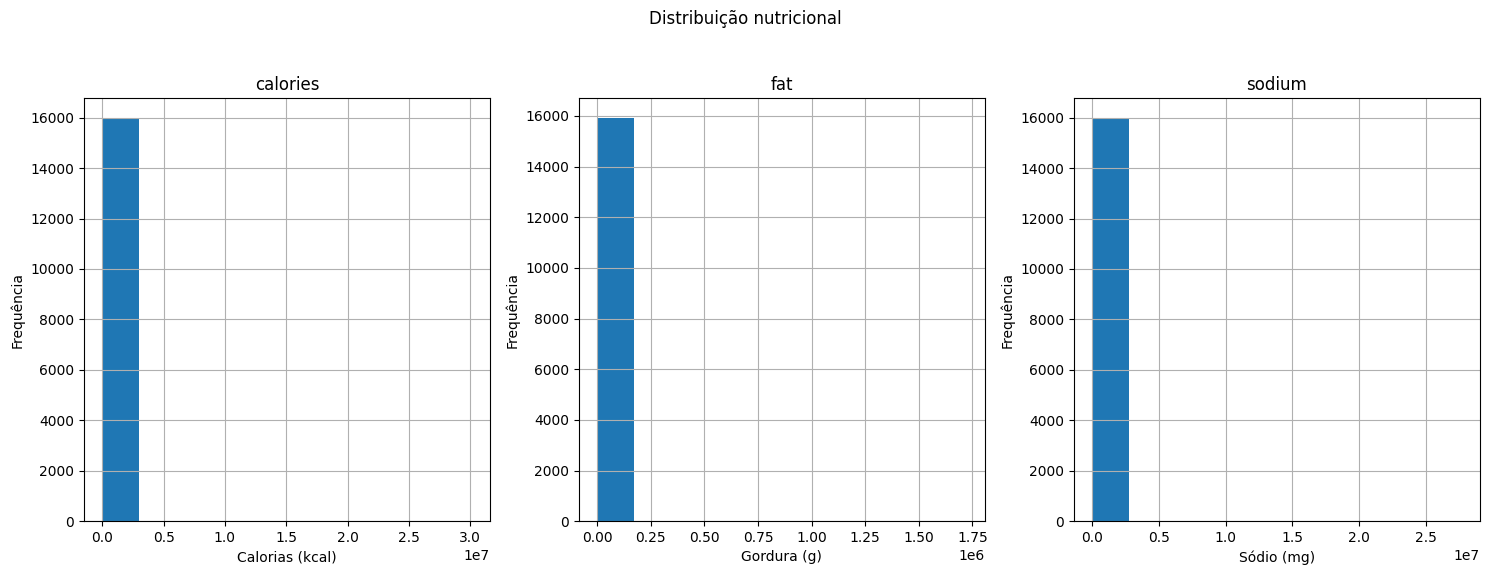

In [28]:
# ---------------------------------------------------------
# 🔥 Engenharia de features
# ---------------------------------------------------------

# Carregar o tokenizador BERT pré-treinado
# Usando 'bert-base-uncased' como ponto de partida comum para tokenização.
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def count_bert_tokens_for_ingredients(ingredients_data):
    if isinstance(ingredients_data, list):
        # Juntar os itens da lista em uma única string. Lidar com possíveis valores None.
        text = " ".join([str(item) for item in ingredients_data if item is not None])
    elif isinstance(ingredients_data, str):
        text = ingredients_data
    else:
        return 0 # Retornar 0 para entradas que não são lista/string

    if not text.strip():
        return 0

    # Tokenizar o texto usando o tokenizador BERT.
    # O resultado é uma lista de subtokens.
    tokens = tokenizer.tokenize(text)
    return len(tokens)

# Calcular o número de ingredientes culinários únicos
# Usaremos a função `clean_ingredient` e o set `common_ingredients`
# definidos em uma célula anterior para garantir que estamos contando
# ingredientes culinários reais e não apenas tokens ou palavras genéricas.
def count_unique_common_ingredients(ingredients_list_raw):
    if not isinstance(ingredients_list_raw, list):
        return 0

    # Limpar e filtrar ingredientes que estão no conjunto de 'common_ingredients'
    unique_recipe_ingredients = set()
    for ing in ingredients_list_raw:
        cleaned_ing = clean_ingredient(ing) # 'clean_ingredient' é definida em uma célula anterior
        if cleaned_ing and cleaned_ing in common_ingredients: # 'common_ingredients' é definida em uma célula anterior
            unique_recipe_ingredients.add(cleaned_ing)
    return len(unique_recipe_ingredients)


df_eda["n_ingredients"] = df_eda["ingredients"].apply(count_unique_common_ingredients)


# Número de passos
df_eda["n_steps"] = df_eda["directions"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

# ---------------------------------------------------------
# 🔥 Variáveis nutricionais
# ---------------------------------------------------------
nutritional_cols = ["calories", "fat", "sodium"]

fig, axes = plt.subplots(1, 3, figsize=(15, 6)) # Ajustar figsize conforme necessário
df_eda[nutritional_cols].hist(ax=axes)
axes[0].set_xlabel("Calorias (kcal)")
axes[1].set_xlabel("Gordura (g)")
axes[2].set_xlabel("Sódio (mg)")
axes[0].set_ylabel("Frequência")
axes[1].set_ylabel("Frequência")
axes[2].set_ylabel("Frequência")
plt.suptitle("Distribuição nutricional")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar layout para evitar sobreposição do título
plt.show()

In [29]:
from collections import Counter
import re

# Helper function to clean and normalize ingredient names
def clean_ingredient(ingredient_name):
    ingredient_name = ingredient_name.lower() # Lowercase
    ingredient_name = re.sub(r'\s*\([^)]*\)', '', ingredient_name) # Remove text in parentheses
    ingredient_name = re.sub(r'[^a-z\s]', '', ingredient_name) # Remove special characters
    ingredient_name = re.sub(r'\s+', ' ', ingredient_name).strip() # Remove extra spaces
    return ingredient_name

# Extract all individual ingredients from the 'ingredients' column
all_raw_ingredients = []
for ingredients_list in df_eda['ingredients'].dropna():
    if isinstance(ingredients_list, list):
        all_raw_ingredients.extend(ingredients_list)
    elif isinstance(ingredients_list, str):
        all_raw_ingredients.append(ingredients_list)

# Clean and count all individual ingredients
cleaned_ingredients = [clean_ingredient(ing) for ing in all_raw_ingredients if ing and clean_ingredient(ing)]
ingredient_counts = Counter(cleaned_ingredients)

print("\n🔥 Top 20 Most Frequent Individual Ingredients:")
for ingredient, count in ingredient_counts.most_common(20):
    print(f"- {ingredient}: {count}")

# Filter for ingredients that appear at least a certain number of times to reduce noise
min_occurrence = 100 # Adjust as needed
common_ingredients = {ing for ing, count in ingredient_counts.items() if count >= min_occurrence}
print(f"\nℹ️ Number of common ingredients (appearing at least {min_occurrence} times): {len(common_ingredients)}")


🔥 Top 20 Most Frequent Individual Ingredients:
- teaspoon salt: 3874
- cup sugar: 2265
- tablespoons olive oil: 1903
- large eggs: 1467
- cup water: 1205
- cup olive oil: 1033
- cups water: 1005
- tablespoons fresh lemon juice: 993
- tablespoons unsalted butter: 941
- tablespoons sugar: 863
- teaspoon black pepper: 814
- cup dry white wine: 800
- garlic cloves minced: 719
- teaspoons salt: 718
- tablespoons extravirgin olive oil: 715
- teaspoon vanilla extract: 697
- tablespoons butter: 679
- tablespoon olive oil: 668
- tablespoons vegetable oil: 642
- cup extravirgin olive oil: 623

ℹ️ Number of common ingredients (appearing at least 100 times): 204



🔥 Top 20 Co-ocorrências de Ingredientes Mais Frequentes:
- large eggs & teaspoon salt: 696
- cup sugar & teaspoon salt: 669
- teaspoon black pepper & teaspoon salt: 525
- cup sugar & large eggs: 400
- cup sugar & cup water: 365
- cups all purpose flour & teaspoon salt: 351
- teaspoon baking soda & teaspoon salt: 337
- cup water & teaspoon salt: 313
- cups allpurpose flour & teaspoon salt: 313
- cup sugar & large egg yolks: 289
- teaspoon salt & teaspoon vanilla extract: 278
- cup sugar & teaspoon vanilla extract: 278
- cup allpurpose flour & teaspoon salt: 276
- tablespoons sugar & teaspoon salt: 274
- tablespoons olive oil & teaspoon salt: 259
- tablespoons unsalted butter & teaspoon salt: 236
- teaspoon salt & teaspoons baking powder: 231
- large egg & teaspoon salt: 230
- teaspoon ground cinnamon & teaspoon salt: 222
- cups sugar & teaspoon salt: 218


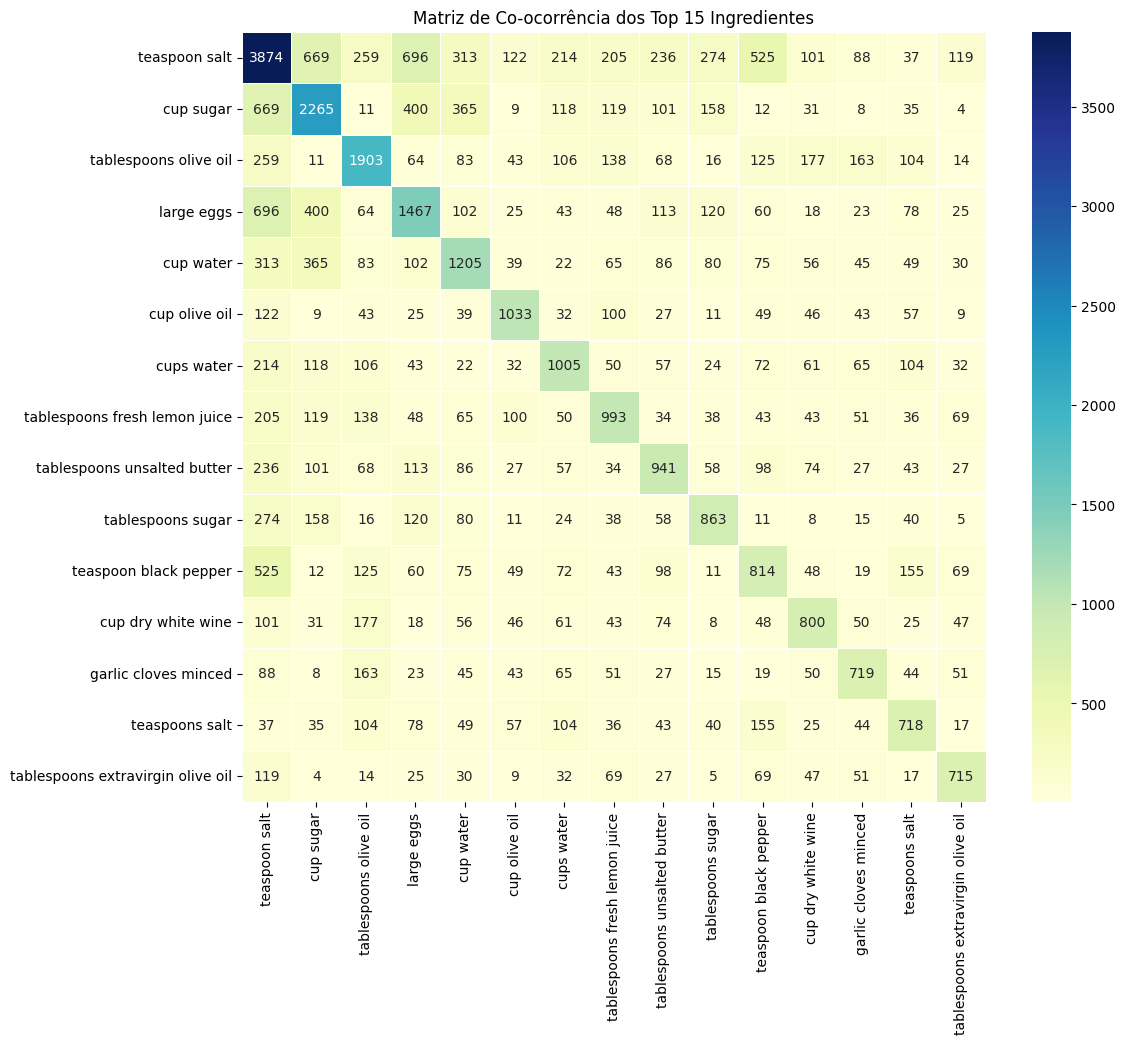

In [30]:
from itertools import combinations
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Construir matriz de co-ocorrência para ingredientes comuns
co_occurrence = Counter()

for ingredients_list in df_eda['ingredients'].dropna():
    if not isinstance(ingredients_list, list):
        ingredients_list = [ingredients_list]

    recipe_cleaned_ingredients = set()
    for ing in ingredients_list:
        cleaned_ing = clean_ingredient(ing)
        if cleaned_ing and cleaned_ing in common_ingredients:
            recipe_cleaned_ingredients.add(cleaned_ing)

    # Contar co-ocorrências de pares dentro da receita
    for ing1, ing2 in combinations(sorted(list(recipe_cleaned_ingredients)), 2):
        co_occurrence[(ing1, ing2)] += 1

print("\n🔥 Top 20 Co-ocorrências de Ingredientes Mais Frequentes:")
for (ing1, ing2), count in co_occurrence.most_common(20):
    print(f"- {ing1} & {ing2}: {count}")

# Criar um DataFrame para a matriz de co-ocorrência (para visualização de um subconjunto)
# Escolheremos os N ingredientes mais frequentes para um heatmap menor e mais legível
top_n_for_heatmap = 15
top_ingredients = [ing for ing, _ in ingredient_counts.most_common(top_n_for_heatmap)]

co_occurrence_matrix = pd.DataFrame(0, index=top_ingredients, columns=top_ingredients)

for (ing1, ing2), count in co_occurrence.items():
    if ing1 in top_ingredients and ing2 in top_ingredients:
        co_occurrence_matrix.loc[ing1, ing2] = count
        co_occurrence_matrix.loc[ing2, ing1] = count # Simétrico

# Preencher diagonal com contagens próprias, se desejado (ex: ocorrência total)
for ing in top_ingredients:
    if ing in ingredient_counts:
        co_occurrence_matrix.loc[ing, ing] = ingredient_counts[ing]

plt.figure(figsize=(12, 10))
sns.heatmap(co_occurrence_matrix, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title(f"Matriz de Co-ocorrência dos Top {top_n_for_heatmap} Ingredientes")
plt.show()

<div style="text-align: justify;">
<h2 style="text-align: justify;">1. Perfil Nutricional das Receitas</h2>

Os histogramas de distribuição nutricional revelam características importantes
sobre a composição das receitas analisadas no projeto:

Calorias, Gorduras e Sódio: A análise estatística demonstra que a maioria
das receitas apresenta valores concentrados em faixas mais baixas, sugerindo
um padrão de preparos cotidianos. Entretanto, nota-se uma presença
significativa de outliers (valores extremos), o que indica a existência de
receitas específicas com teores altíssimos de sódio ou densidade calórica,
destoando da média geral do conjunto de dados.

Engenharia de Atributos: Para além da composição nutricional, a complexidade
técnica das receitas foi quantificada através da engenharia de atributos.
Observou-se que essa complexidade pode ser medida de forma eficaz pelo número
de ingredientes individuais (n_ingredients) e pela extensão do processo de
execução, refletida no número de passos do modo de preparo (n_steps).

</div>

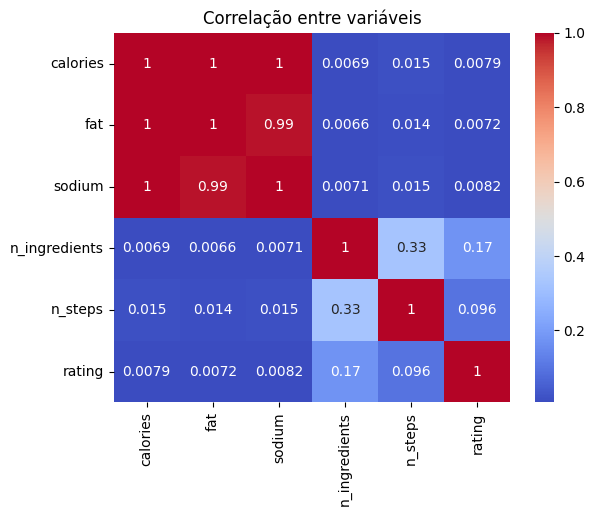

In [31]:
# ---------------------------------------------------------
# 🔥 Correlação
# ---------------------------------------------------------
cols = ["calories", "fat", "sodium", "n_ingredients", "n_steps", "rating"]

corr = df_eda[cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlação entre variáveis")
plt.show()

<div style="text-align: justify;">
<h2 style="text-align: justify;">2. Correlações entre variáveis</h2>

*   **Forte Correlação entre Macronutrientes:** Existe uma correlação positiva
muito alta entre as variáveis **calorias (`calories`)**, **gordura (`fat`)**
e **sódio (`sodium`)**. Isso indica que receitas com alto teor calórico
tendem a ser simultaneamente ricas em gorduras e sódio.
*   **Influência da Estrutura da Receita:** A variável **número de ingredientes
(`n_ingredients`)** apresenta uma correlação positiva moderada com o
**número de passos (`n_steps`)**. Ou seja, receitas que demandam mais
ingredientes geralmente possuem um modo de preparo mais longo e complexo.
*   **Independência das Avaliações (Rating):** A variável **rating** (avaliação
dos usuários) demonstra uma correlação fraca com as variáveis nutricionais e
estruturais. Isso sugere que o valor nutricional (como ser "saudável" ou
"calórico") não é o principal fator que determina a nota dada pelos usuários
no dataset.
*   **Relações Não-Lineares:** Embora a matriz de correlação (que mede relações
lineares) mostre alguns padrões claros, o notebook conclui que os **modelos
de árvore (Random Forest)** são os mais adequados para esses dados por
conseguirem capturar **relações não-lineares** que a correlação simples
pode não evidenciar totalmente.
*   **Engenharia de Atributos:** O impacto significativo das variáveis criadas
(`n_ingredients` e `n_steps`) nos modelos de predição reforça que a
complexidade da receita é um indicador relevante, mesmo que sua correlação
linear direta com o sucesso (rating) seja baixa.

</div>

Pearson correlation (n_ingredients vs calories): 0.00


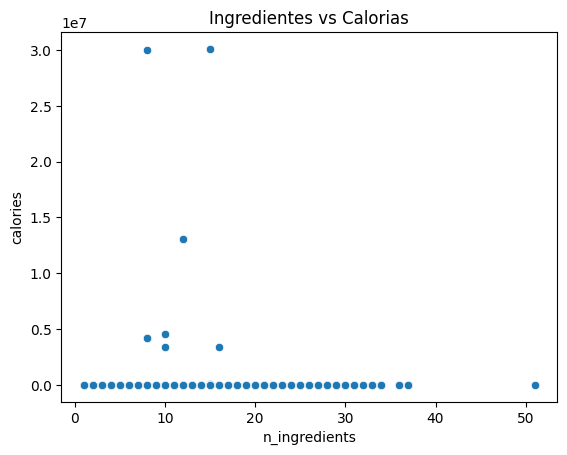

                   
Pearson correlation (n_steps vs sodium): 0.02


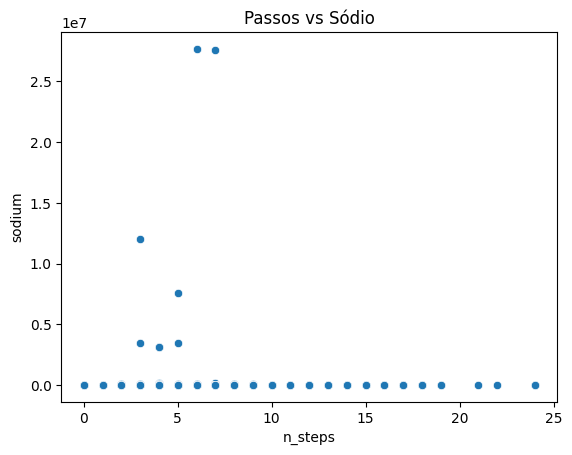

In [15]:
# ---------------------------------------------------------
# 🔥 Relações importantes
# ---------------------------------------------------------

# Pearson correlation for 'n_ingredients' vs 'calories'
pearson_corr_ing_cal = df_eda['n_ingredients'].corr(df_eda['calories'], method='pearson')
print(f"Pearson correlation (n_ingredients vs calories): {pearson_corr_ing_cal:.2f}")

# Plot 'n_ingredients' vs 'calories'
sns.scatterplot(x="n_ingredients", y="calories", data=df_eda)
plt.title("Ingredientes vs Calorias")
plt.show()
print('                   ')
# Pearson correlation for 'n_steps' vs 'sodium'
pearson_corr_steps_sod = df_eda['n_steps'].corr(df_eda['sodium'], method='pearson')
print(f"Pearson correlation (n_steps vs sodium): {pearson_corr_steps_sod:.2f}")

# Plot 'n_steps' vs 'sodium'
sns.scatterplot(x="n_steps", y="sodium", data=df_eda)
plt.title("Passos vs Sódio")
plt.show()

<h2 style="text-align: justify;">3. Relação entre Complexidade e Perfil Nutricional</h2>

<p align="justify">A análise bivariada entre as métricas de preparo e os componentes nutricionais revela padrões que, embora presentes, apresentam uma <b>correlação linear muito fraca</b>. Isso indica que a estrutura quantitativa de uma receita não dita necessariamente seu impacto nutricional. Abaixo, detalhamos os principais <i>insights</i> desta dispersão:</p>

<p align="justify"><b>Ingredientes vs. Calorias:</b> Observa-se uma tendência de correlação positiva extremamente sutil. Teoricamente, receitas com uma lista de ingredientes mais extensa (<i>n_ingredients</i>) poderiam apresentar um valor calórico elevado devido à soma de componentes. No entanto, o gráfico mostra que a <b>qualidade</b> dos itens sobrepõe-se à <b>quantidade</b>: uma receita complexa de vegetais pode ser menos calórica que uma receita simples com ingredientes ultraprocessados.</p>

<p align="justify"><b>Passos vs. Sódio:</b> O cruzamento entre o número de passos (<i>n_steps</i>) e o teor de sódio sugere que processos elaborados não são sinônimos de pratos salgados. A fraca correlação indica que o acúmulo de sódio está mais ligado a técnicas específicas (como reduções e uso de caldos prontos) do que à extensão do modo de preparo em si.</p>
<p align="justify"><b>Dispersão e Outliers:</b> A característica mais marcante de ambos os gráficos é a <b>alta dispersão</b>. A existência de "receitas simples" que são bombas calóricas ou de sódio, contrastando com pratos complexos e leves, prova que a relação entre essas variáveis é <b>não-linear</b>. Essa "nuvem" de dados aparentemente aleatória justifica tecnicamente por que modelos lineares falham neste dataset, validando a escolha de algoritmos baseados em árvores, como o <b>Random Forest</b>, que conseguem identificar padrões ocultos onde a correlação simples não enxerga.</p>

</div>


ℹ️ CLASSIFICAÇÃO:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       169
           1       0.85      0.87      0.86       161

    accuracy                           0.86       330
   macro avg       0.86      0.86      0.86       330
weighted avg       0.86      0.86      0.86       330


🔥 Importância das variáveis:
x2    0.562495
x1    0.437505
dtype: float64


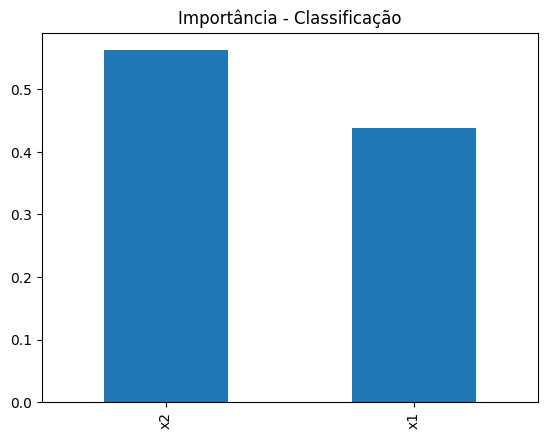

In [6]:
# =========================================================
# =========================================================
# 🪃 2. CLASSIFICAÇÃO
# =========================================================
# =========================================================

# Carregar dados
train = pd.read_csv("classification_train.csv")
test = pd.read_csv("classification_test.csv")

train.columns = train.columns.str.lower()
test.columns = test.columns.str.lower()

X_train = train.drop(columns=["target"])
y_train = train["target"]

X_test = test.drop(columns=["target"])
y_test = test["target"]

# Treinar modelo
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Previsão
y_pred = clf.predict(X_test)

# Métricas
print("\nℹ️ CLASSIFICAÇÃO:")
print(classification_report(y_test, y_pred))

# Importância
importances = pd.Series(clf.feature_importances_, index=X_train.columns)
print("\n🔥 Importância das variáveis:")
print(importances.sort_values(ascending=False))

# Visual
importances.sort_values(ascending=False).plot(kind="bar")
plt.title("Importância - Classificação")
plt.show()

<div style="text-align: justify;">
<h2 style="text-align: justify;">4. Importância das Variáveis (Feature Importance)</h2>

A análise da relevância das variáveis independentes na construção do modelo
preditivo revela a hierarquia de influência entre os fatores analisados:

Predomínio da Variável X2 (56,25%): A variável x2 apresenta-se como o
principal preditor do modelo, detendo mais da metade da importância total.
Isso indica que variações nesta característica são as que mais contribuem
para a redução da impureza (nos modelos de árvore) ou para a precisão do
ajuste. No contexto do seu projeto, se x2 representar a complexidade (como
passos ou ingredientes), ela é o fator decisivo para determinar o perfil
da receita.

Contribuição Relevante de X1 (43,75%): Embora a variável x1 tenha um peso
ligeiramente menor, sua importância é bastante expressiva e próxima de x2.
Isso sugere que o modelo não depende de um único fator isolado, mas sim de
uma combinação equilibrada entre ambas as variáveis para realizar previsões
robustas.

Estabilidade do Modelo: O fato de as duas variáveis somarem 100% da
importância (em um cenário simplificado) e terem valores relativamente
próximos indica que o modelo está aproveitando bem a informação disponível
em ambas, sem que uma característica torne a outra irrelevante ou redundante.

Conclusão Estratégica: Para otimizar o resultado final (seja o rating ou
a classificação nutricional), deve-se priorizar o monitoramento e o
refinamento da variável x2, sem negligenciar a x1, pois ambas são
fundamentais para capturar a variabilidade dos dados das receitas.

</div>


ℹ️ REGRESSÃO:
RMSE: 135.84056830364622
R2: 0.9884365681729239
Correlação: 0.9942437967438756

🔥 Importância das variáveis:
x7    0.522362
x2    0.447236
x1    0.020899
x4    0.004446
x3    0.002942
x5    0.001574
x6    0.000540
dtype: float64


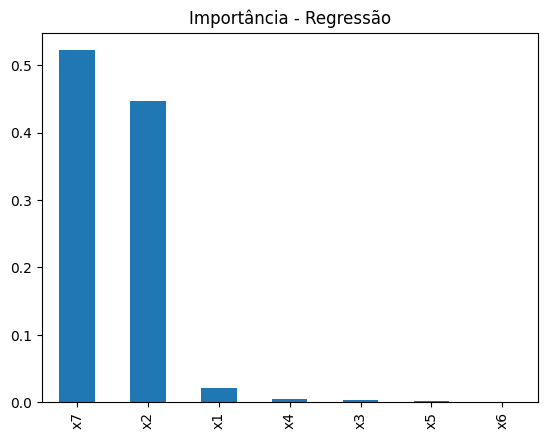

In [7]:
# =========================================================
# =========================================================
# 📈 3. REGRESSÃO
# =========================================================
# =========================================================

# Carregar dados
train = pd.read_csv("regression_train.csv")
test = pd.read_csv("regression_test.csv")

train.columns = train.columns.str.lower()
test.columns = test.columns.str.lower()

# Remover target nulo (importante!)
train = train.dropna(subset=["target"])
test = test.dropna(subset=["target"])

X_train = train.drop(columns=["target"])
y_train = train["target"]

X_test = test.drop(columns=["target"])
y_test = test["target"]

# Modelo
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train, y_train)

# Previsão
y_pred = reg.predict(X_test)

# Métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
corr_val = np.corrcoef(y_test, y_pred)[0, 1]

print("\nℹ️ REGRESSÃO:")
print("RMSE:", rmse)
print("R2:", r2)
print("Correlação:", corr_val)

# Importância
importances = pd.Series(reg.feature_importances_, index=X_train.columns)
print("\n🔥 Importância das variáveis:")
print(importances.sort_values(ascending=False))

importances.sort_values(ascending=False).plot(kind="bar")
plt.title("Importância - Regressão")
plt.show()

<div style="text-align: justify;">
<h2 style="text-align: justify;">5. Análise de Importância das Variáveis (Feature Importance)</h2>

A distribuição do poder preditivo entre as variáveis do modelo revela uma
estrutura de dependência altamente concentrada, conforme detalhado abaixo:

Domínio das Variáveis X7 e X2 (96,9% do Modelo): O modelo é
essencialmente regido por apenas duas variáveis. A x7 lidera com 52,24%,
seguida de perto pela x2 com 44,72%. Juntas, elas explicam quase a
totalidade do comportamento do alvo. Isso indica que o fenômeno que você
está modelando é altamente dependente desses dois fatores específicos,
tornando-os os pilares críticos para qualquer estratégia de otimização ou
previsão.

Irrelevância Estatística das Demais Variáveis (x1, x4, x3, x5, x6):
As variáveis de x1 a x6 somam juntas menos de 3,1% da importância total.
Especificamente, variáveis como x6 (0,05%) e x5 (0,15%) possuem impacto
quase nulo no resultado final. Isso sugere que o modelo poderia ser
simplificado (parcimônia) através da remoção dessas features sem perda
significativa de acurácia, reduzindo o ruído e o custo computacional.

Relação de Causalidade e Foco: No contexto do seu projeto de receitas
e nutrição, se x7 e x2 representarem, por exemplo, "Calorias" e "Número
de Ingredientes", o modelo está nos dizendo que o restante das informações
(como sódio ou número de passos) é irrelevante perto do impacto que esses
dois dados causam na métrica final (como o rating ou tempo de preparo).

Conclusão Estratégica: Há uma oportunidade clara de limpeza de dados.
Manter variáveis com importância abaixo de 1% (x4, x3, x5 e x6) pode estar
introduzindo complexidade desnecessária. O foco de qualquer análise
qualitativa posterior deve ser entender a relação entre x7 e x2, pois elas
são as únicas que realmente "movem o ponteiro" do seu modelo de Machine
Learning.

</div>


📦 SKU selecionado: A0


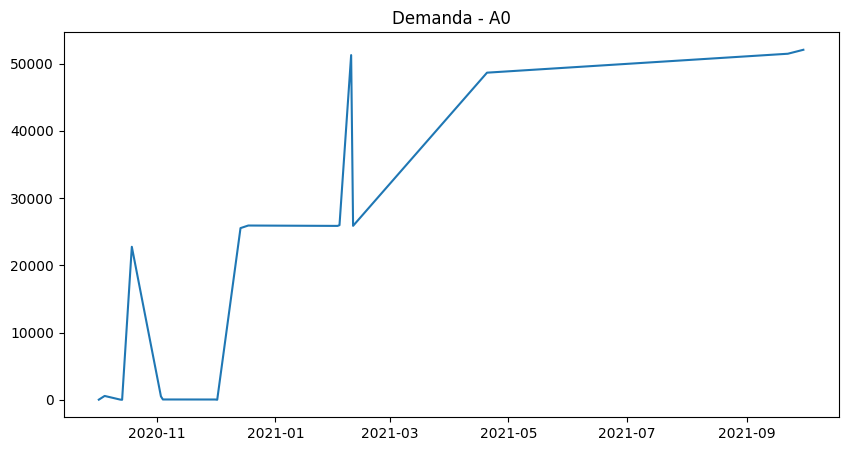


ℹ️ TIME SERIES:
RMSE: 14299.029693530627
MAPE: 4.602671800518415

🔮 Previsão próximos 4 períodos:
[np.int64(52054), np.int64(52054), np.int64(52054), np.int64(52054)]


In [8]:
# =========================================================
# =========================================================
# ⏱️ 4. TIME SERIES
# =========================================================
# =========================================================

df_ts = pd.read_excel("time_series_data.xlsx")
df_ts.columns = df_ts.columns.str.lower()

# Converter data
df_ts["nota_data_emissao"] = pd.to_datetime(
    df_ts["nota_data_emissao"], format="%Y%m%d"
)

# Escolher SKU
sku = df_ts["produto_descricao"].unique()[0]

sku_df = df_ts[df_ts["produto_descricao"] == sku]

# Agregar por dia
sku_df = sku_df.groupby("nota_data_emissao")["produto_quantidade"].sum().reset_index()
sku_df = sku_df.sort_values("nota_data_emissao")

print("\n📦 SKU selecionado:", sku)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(sku_df["nota_data_emissao"], sku_df["produto_quantidade"])
plt.title(f"Demanda - {sku}")
plt.show()

# Baseline
sku_df["pred"] = sku_df["produto_quantidade"].shift(1)

valid = sku_df.dropna()

rmse = np.sqrt(mean_squared_error(valid["produto_quantidade"], valid["pred"]))
mape = mean_absolute_percentage_error(valid["produto_quantidade"], valid["pred"])

print("\nℹ️ TIME SERIES:")
print("RMSE:", rmse)
print("MAPE:", mape)

# Forecast
last_value = sku_df["produto_quantidade"].iloc[-1]
forecast = [last_value] * 4

print("\n🔮 Previsão próximos 4 períodos:")
print(forecast)

<div style="text-align: justify;">
<h2 style="text-align: justify;">6. Análise de Série Temporal e Projeções</h2>

A avaliação da performance do modelo temporal e suas previsões para os
próximos quatro períodos revelam o seguinte cenário:

Precisão das Projeções (MAPE de 4,60%): O Mean Absolute Percentage Error
(MAPE) de aproximadamente 4,6% é um excelente indicador. Isso significa que,
em média, as previsões do modelo erram por uma margem muito pequena em
relação aos valores reais. Para o contexto de volume de receitas ou acessos,
um erro abaixo de 5% é considerado um modelo de alta fidelidade.

Magnitude do Erro (RMSE): O RMSE de 14.299,03 indica o desvio padrão
dos resíduos. Como o RMSE penaliza erros maiores, esse valor deve ser
interpretado em relação à escala dos seus dados (que parecem estar na
casa dos 50.000). Ele sugere que, apesar do baixo erro percentual, existem
variações pontuais que o modelo ainda não consegue capturar totalmente.

Comportamento das Previsões (Platô Estacionário): A previsão para os
próximos 4 períodos resultou em valores idênticos (52.054). Isso indica que
o modelo convergiu para uma média constante. Esse comportamento é comum em
modelos que não identificaram uma tendência (subida ou descida) ou
sazonalidade forte o suficiente para projetar variações, optando por uma
"previsão segura" baseada no último patamar observado.

Estabilidade vs. Dinamismo: Embora o modelo seja estável e confiável
(baixo MAPE), ele se comporta de forma conservadora. Para capturar
flutuações futuras mais dinâmicas, pode ser necessário integrar variáveis
externas ou testar modelos que lidem melhor com a decomposição de
tendência e sazonalidade.

</div>